# 🔍 01 — Khám phá dữ liệu (EDA) — SuperStore

**Mục tiêu:** hiểu dữ liệu trước khi xây pipeline & mô hình. Trả lời:
- Dữ liệu sạch tới đâu? (thiếu, trùng, kiểu dữ liệu)
- Sales / Profit / Discount phân phối ra sao? Có outlier không?
- **Đơn hàng nào đang lỗ — và chiết khấu liên quan thế nào?** (đặt nền cho mô hình profit-driver)
- Cơ cấu doanh thu theo Category / Segment / Region.
- Tính mùa vụ có **ổn định qua các năm** không? (kiểm chứng giả định của `pace_weight`)

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('src')
from utils import load_and_shift, monthly_weights

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Đọc dữ liệu đã dịch năm (2023–2026), dùng đúng hàm pipeline dùng
df = load_and_shift('SampleSuperstore.csv', shift_years=9)
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
print('Kích thước:', df.shape)
df.head()

Kích thước: (9994, 23)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2025-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2025,11
1,2,CA-2016-152156,2025-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2025,11
2,3,CA-2016-138688,2025-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2025,6
3,4,US-2015-108966,2024-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2024,10
4,5,US-2015-108966,2024-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2024,10


## 1. Tổng quan & chất lượng dữ liệu

In [2]:
print('Khoảng thời gian:', df['Order Date'].min().date(), '→', df['Order Date'].max().date())
print('Số dòng:', len(df), '| Số đơn (Order ID):', df['Order ID'].nunique(),
      '| Số khách:', df['Customer ID'].nunique())
print('\nGiá trị thiếu mỗi cột:')
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else '  (Không có giá trị thiếu)')
print('\nSố dòng trùng lặp hoàn toàn:', df.duplicated().sum())
print('\nKiểu dữ liệu:')
print(df.dtypes)

Khoảng thời gian: 2023-01-03 → 2026-12-30
Số dòng: 9994 | Số đơn (Order ID): 5009 | Số khách: 793

Giá trị thiếu mỗi cột:
  (Không có giá trị thiếu)

Số dòng trùng lặp hoàn toàn: 0

Kiểu dữ liệu:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date                   str
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
Month                     int32
dtype: object


In [3]:
# Thống kê mô tả các biến số
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


## 2. Phân phối các biến số

Sales/Profit thường lệch phải mạnh (long tail) — vài đơn rất lớn. Quan sát để biết có cần xử lý outlier / log-scale khi mô hình hóa.

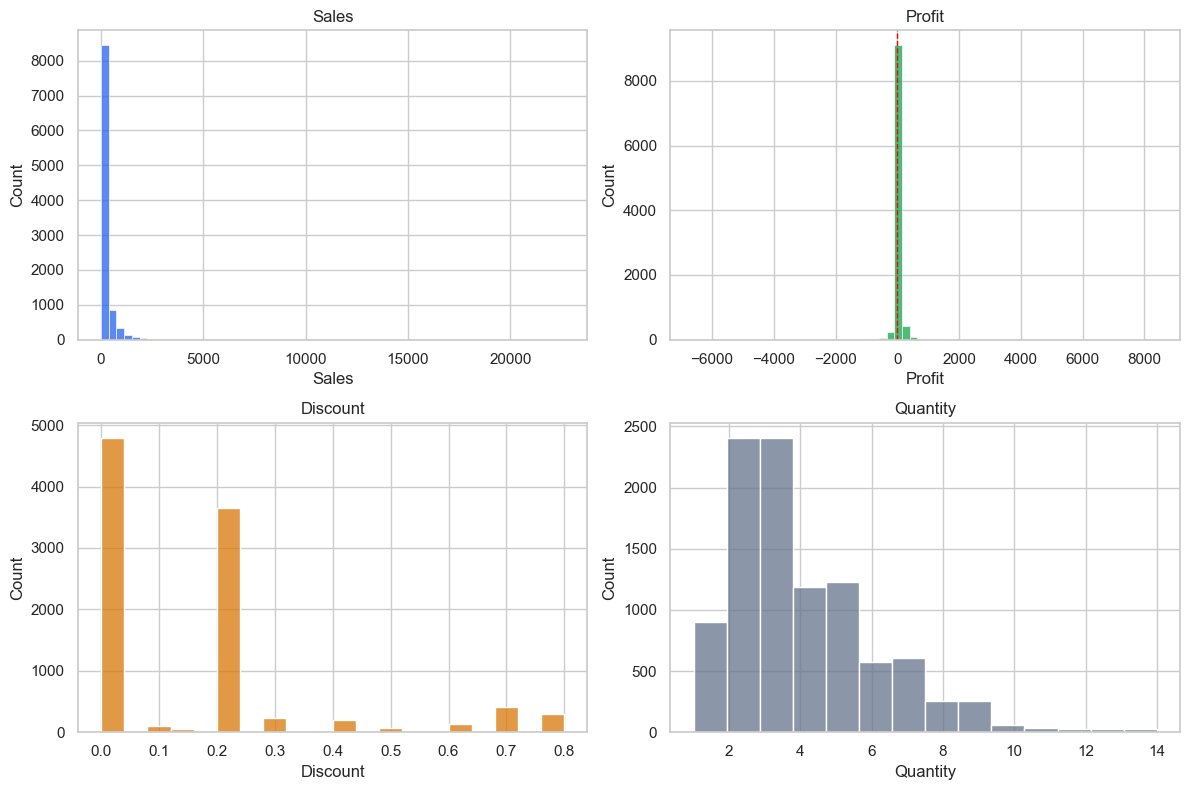

Độ lệch (skew) — Sales: 12.97 | Profit: 7.56
Profit âm: 18.7% số đơn


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Sales'],    bins=60, ax=axes[0,0], color='#2563EB'); axes[0,0].set_title('Sales')
sns.histplot(df['Profit'],   bins=60, ax=axes[0,1], color='#16a34a'); axes[0,1].set_title('Profit')
axes[0,1].axvline(0, color='red', ls='--', lw=1)
sns.histplot(df['Discount'], bins=20, ax=axes[1,0], color='#d97706'); axes[1,0].set_title('Discount')
sns.histplot(df['Quantity'], bins=14, ax=axes[1,1], color='#64748B'); axes[1,1].set_title('Quantity')
plt.tight_layout(); plt.show()

print(f"Độ lệch (skew) — Sales: {df['Sales'].skew():.2f} | Profit: {df['Profit'].skew():.2f}")
print(f"Profit âm: {(df['Profit']<0).mean()*100:.1f}% số đơn")

## 3. Outlier & đơn hàng lỗ

Hai vấn đề quan trọng cho cả pace_weight (outlier bóp méo trọng số tháng) lẫn mô hình lợi nhuận.

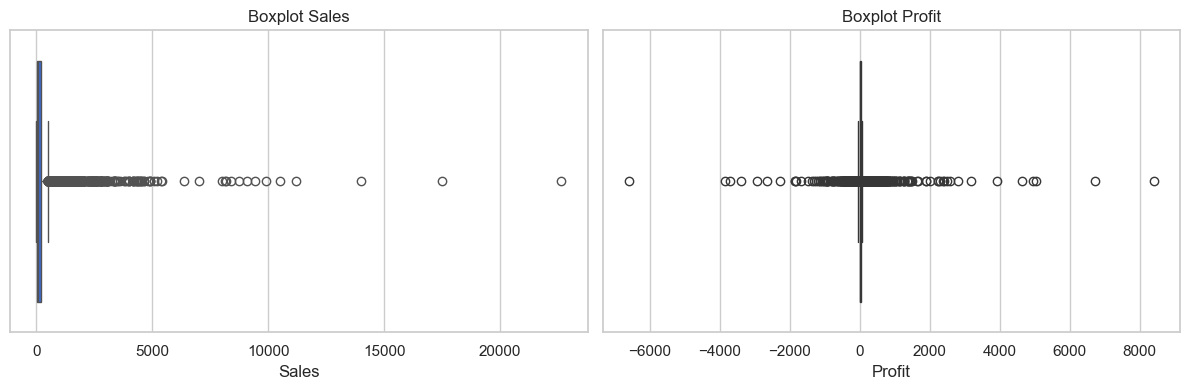

Đơn lỗ: 1,871 (18.7% số đơn)
Tổng lỗ:  $-156,131
Tổng lãi: $442,528

Top 5 Sub-Category lỗ nhiều nhất:
Sub-Category
Binders     -38510.0
Tables      -32412.0
Machines    -30119.0
Bookcases   -12152.0
Chairs       -9881.0
Name: Profit, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Sales'],  ax=axes[0], color='#2563EB'); axes[0].set_title('Boxplot Sales')
sns.boxplot(x=df['Profit'], ax=axes[1], color='#16a34a'); axes[1].set_title('Boxplot Profit')
plt.tight_layout(); plt.show()

loss = df[df['Profit'] < 0]
print(f'Đơn lỗ: {len(loss):,} ({len(loss)/len(df)*100:.1f}% số đơn)')
print(f'Tổng lỗ:  ${loss["Profit"].sum():,.0f}')
print(f'Tổng lãi: ${df[df["Profit"]>0]["Profit"].sum():,.0f}')
print('\nTop 5 Sub-Category lỗ nhiều nhất:')
print(loss.groupby('Sub-Category')['Profit'].sum().sort_values().head().round(0))

## 4. Cơ cấu theo Category / Segment / Region

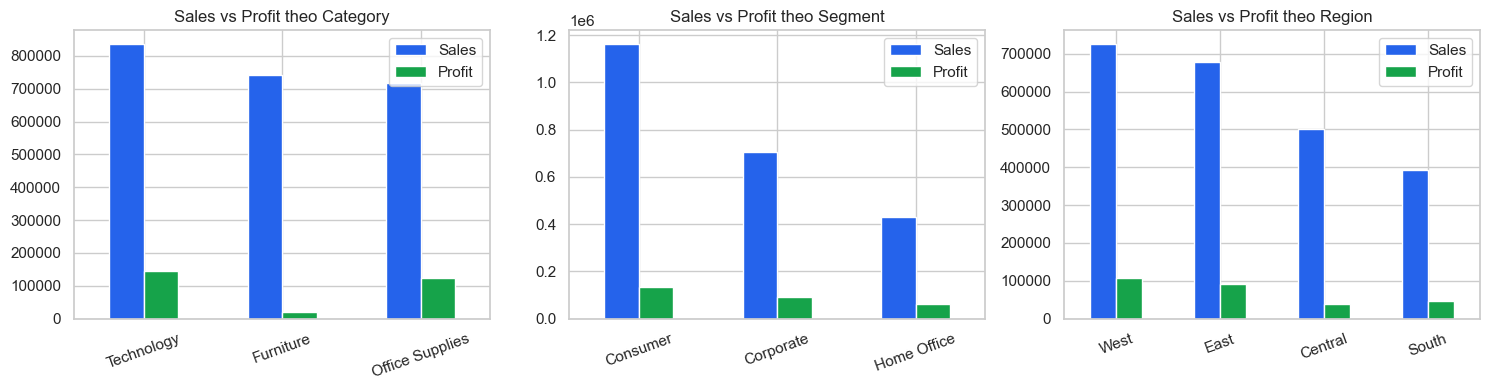

Biên lợi nhuận theo Sub-Category (thấp → cao):
                 Sales   Profit  Margin%
Sub-Category                            
Tables        206966.0 -17725.0     -9.0
Bookcases     114880.0  -3473.0     -3.0
Supplies       46674.0  -1189.0     -2.0
Machines      189239.0   3385.0      2.0
Chairs        328449.0  26590.0      8.0
Storage       223844.0  21279.0     10.0
Phones        330007.0  44516.0     14.0
Furnishings    91705.0  13059.0     14.0
Binders       203413.0  30222.0     15.0
Appliances    107532.0  18138.0     17.0
Art            27119.0   6528.0     24.0
Accessories   167380.0  41937.0     25.0
Fasteners       3024.0    950.0     31.0
Copiers       149528.0  55618.0     37.0
Envelopes      16476.0   6964.0     42.0
Paper          78479.0  34054.0     43.0
Labels         12486.0   5546.0     44.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Category', 'Segment', 'Region']):
    g = df.groupby(col).agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
    g = g.sort_values('Sales', ascending=False)
    g.plot(kind='bar', ax=ax, color=['#2563EB', '#16a34a'])
    ax.set_title(f'Sales vs Profit theo {col}'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# Biên lợi nhuận theo Sub-Category (cảnh báo nhóm margin âm)
sc = df.groupby('Sub-Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
sc['Margin%'] = (sc['Profit'] / sc['Sales'] * 100).round(1)
print('Biên lợi nhuận theo Sub-Category (thấp → cao):')
print(sc.sort_values('Margin%')[['Sales', 'Profit', 'Margin%']].round(0))

## 5. Tương quan & quan hệ Discount → Profit ⭐

Đây là phát hiện cốt lõi và là động lực cho mô hình profit-driver: chiết khấu cao có kéo lợi nhuận xuống âm không?

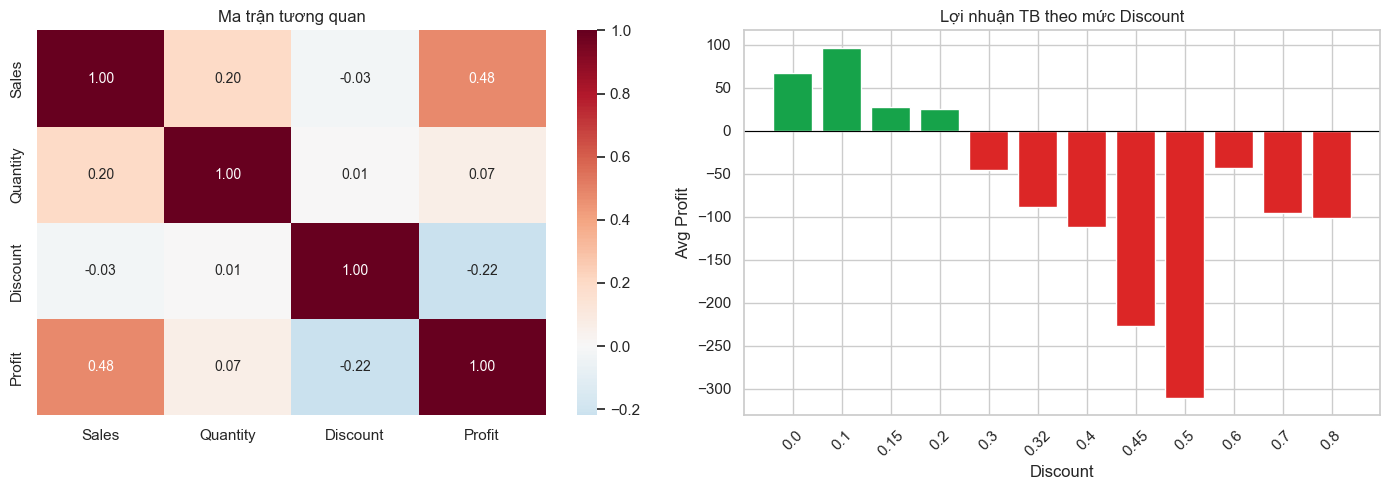

⚠️ Lợi nhuận TB chuyển âm từ mức chiết khấu ≈ 30% trở lên


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap tương quan biến số
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Ma trận tương quan')

# Lợi nhuận trung bình theo mức chiết khấu
by_disc = df.groupby('Discount').agg(AvgProfit=('Profit','mean'), N=('Profit','size')).reset_index()
colors = ['#dc2626' if p < 0 else '#16a34a' for p in by_disc['AvgProfit']]
axes[1].bar(by_disc['Discount'].astype(str), by_disc['AvgProfit'], color=colors)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Lợi nhuận TB theo mức Discount'); axes[1].set_xlabel('Discount'); axes[1].set_ylabel('Avg Profit')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# Ngưỡng chiết khấu bắt đầu lỗ
neg = by_disc[by_disc['AvgProfit'] < 0]
if len(neg):
    print(f'⚠️ Lợi nhuận TB chuyển âm từ mức chiết khấu ≈ {neg["Discount"].min()*100:.0f}% trở lên')

## 6. Tính mùa vụ có ổn định qua các năm không?

`pace_weight` giả định trọng số tháng của **năm trước** đại diện cho mùa vụ năm nay. Kiểm chứng bằng cách so trọng số tháng của từng năm — nếu các đường gần trùng nhau thì giả định vững; nếu lệch nhiều thì nên dùng **trung bình nhiều năm**.

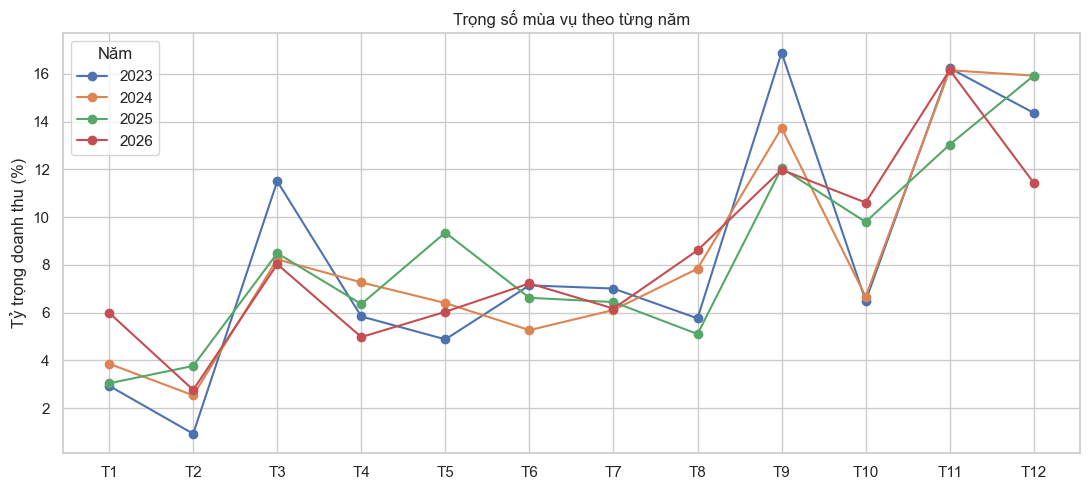

Chênh lệch trọng số (max-min) lớn nhất theo tháng (điểm %):
8     4.90
11    4.49
4     4.47

→ Nếu chênh lệch lớn, nên dùng trung bình nhiều năm thay vì 1 năm cho pace_weight.


In [8]:
plt.figure(figsize=(11, 5))
full_years = [y for y in sorted(df['Year'].unique())
              if df[df['Year']==y]['Month'].nunique() == 12]
for y in full_years:
    w = monthly_weights(df[df['Year'] == y])
    plt.plot(range(1, 13), (w.values * 100), marker='o', label=str(y))
plt.xticks(range(1, 13), [f'T{m}' for m in range(1, 13)])
plt.ylabel('Tỷ trọng doanh thu (%)'); plt.title('Trọng số mùa vụ theo từng năm')
plt.legend(title='Năm'); plt.tight_layout(); plt.show()

# Độ biến động trọng số mỗi tháng giữa các năm
wmat = pd.DataFrame({y: monthly_weights(df[df['Year']==y]).values for y in full_years})
spread = (wmat.max(axis=1) - wmat.min(axis=1)) * 100
print('Chênh lệch trọng số (max-min) lớn nhất theo tháng (điểm %):')
print(spread.round(2).sort_values(ascending=False).head(3).to_string())
print('\n→ Nếu chênh lệch lớn, nên dùng trung bình nhiều năm thay vì 1 năm cho pace_weight.')

## 📌 Kết luận EDA

- **Chất lượng dữ liệu:** không thiếu giá trị, kiểm tra trùng lặp — đủ sạch để phân tích trực tiếp.
- **Phân phối:** Sales & Profit lệch phải mạnh, có outlier — cần lưu ý khi xây mô hình (cân nhắc log/robust).
- **Đơn lỗ:** một tỷ lệ đáng kể đơn hàng có lợi nhuận âm, tập trung ở vài Sub-Category → cơ hội tối ưu margin.
- **Discount → Profit:** tương quan âm rõ rệt; lợi nhuận TB chuyển âm khi chiết khấu vượt ngưỡng → **động lực cho mô hình profit-driver (notebook 02)**.
- **Mùa vụ:** dùng biểu đồ trên để quyết định pace_weight nên dùng 1 năm hay trung bình nhiều năm.

➡️ Tiếp theo: `02_profit_model.ipynb` — dùng XGBoost + SHAP để định lượng yếu tố nào phá biên lợi nhuận.